In [1]:
#import libraries 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load datasets
alternative = pd.read_csv('training-data/alternative.csv')
blues = pd.read_csv('training-data/blues.csv')
classical = pd.read_csv('training-data/classical.csv')
comedy = pd.read_csv('training-data/comedy.csv')
folk = pd.read_csv('training-data/folk.csv')
hiphop = pd.read_csv('training-data/hip-hop.csv')
jazz = pd.read_csv('training-data/jazz.csv')
opera = pd.read_csv('training-data/opera.csv')
pop = pd.read_csv('training-data/pop.csv')
rb = pd.read_csv('training-data/rb.csv')

In [3]:
#inspecting dataset
alternative.head()

,instance_id,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,genre
0,134768,Freddie Gibbs,Triple Threat,12NwYmQT1Mm7gkrCjIuq0d,45,0.02520,0.850,178422,0.412,0.00000,D,0.0948,-7.845,Major,0.2360,130.99,04-Apr,0.663,Alternative
1,97297,Three Days Grace,No More,4yDs61mzPcTod9qrBUE3H9,45,0.00261,0.271,225493,0.916,0.00000,F#,0.1560,-3.141,Minor,0.0581,197.817,04-Apr,0.286,Alternative
2,88412,Solange,Don't You Wait,0AmkrjMDff4ICVNxQhppZA,45,0.27900,0.833,245907,0.579,0.69200,C,0.0997,-6.568,Major,0.0800,?,04-Apr,0.514,Alternative
3,172572,Amy Grant,"Baby, Baby",25AmLrQC1b3Hz9FUGZXF1S,58,0.42600,0.702,236973,0.901,0.00153,C#,0.0368,-4.450,Major,0.0264,97.862,04-Apr,0.919,Alternative
4,194415,empty_field,Livin Right,6KmnejQFYdWUVUJh6zwEce,46,0.00114,0.539,209760,0.915,0.00000,C#,0.0675,-4.251,Minor,0.0601,88.051,04-Apr,0.435,Alternative


In [4]:
#combine all datasets
all_genres = pd.concat([alternative, blues, classical, comedy, folk, hiphop, jazz, opera, pop, rb], ignore_index = True)

#check for missing values
missing_values = all_genres.isnull().sum()

#check for invalid "?" in 'tempo'
missing_tempo = all_genres['tempo'].unique()

#display
missing_values, missing_tempo

(instance_id         0
 artist_name         0
 track_name          0
 track_id            0
 popularity          0
 acousticness        0
 danceability        0
 duration_ms         0
 energy              0
 instrumentalness    0
 key                 0
 liveness            0
 loudness            0
 mode                0
 speechiness         0
 tempo               0
 time_signature      0
 valence             0
 genre               0
 dtype: int64,
 array(['130.99', '197.817', '?', ..., '118.902', '130.213', '148.317'],
       dtype=object))

In [5]:
#Replace "?" for tempo with NaN
all_genres['tempo'] = pd.to_numeric(all_genres['tempo'], errors = 'coerce')

#imputation
all_genres['tempo'].fillna(all_genres['tempo'].median(), inplace = True)

#encode catergorical columns
all_genres['key'] = all_genres['key'].astype('category').cat.codes
all_genres['mode'] = all_genres['mode'].astype('category').cat.codes
all_genres['time_signature'] = all_genres['time_signature'].astype('category').cat.codes

#display
clean_data = all_genres.describe()
clean_data

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,50000.00000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,118922.89754,41.670020,0.474821,0.533403,1.960065e+05,0.515805,0.149052,5.382120,0.244182,-11.013448,0.349120,0.166576,113.135372,2.856880,0.419746
std,57198.25002,18.496416,0.376703,0.188077,1.566169e+05,0.273039,0.300495,3.437205,0.234041,6.706273,0.476697,0.255489,28.261857,0.469128,0.248419
min,20004.00000,0.000000,0.000001,0.058200,-1.000000e+00,0.000243,0.000000,0.000000,0.009670,-47.599000,0.000000,0.022600,34.151000,0.000000,0.000000
25%,69247.75000,29.000000,0.080100,0.406000,1.187925e+05,0.296000,0.000000,3.000000,0.099600,-14.150000,0.000000,0.038200,92.072750,3.000000,0.210000
50%,118822.50000,44.000000,0.442000,0.546000,2.044335e+05,0.543000,0.000066,5.000000,0.133000,-8.906000,0.000000,0.052200,110.043000,3.000000,0.400000
75%,168614.25000,55.000000,0.867000,0.672000,2.593330e+05,0.735000,0.046800,8.000000,0.299000,-6.161000,1.000000,0.141000,129.969000,3.000000,0.607000
max,217850.00000,99.000000,0.996000,0.980000,5.552917e+06,0.998000,0.994000,11.000000,1.000000,3.744000,1.000000,0.965000,239.848000,4.000000,0.986000


In [6]:
#split data into features X and y
X = all_genres.drop(columns = ['instance_id', 'artist_name', 'track_name', 'track_id', 'genre'])
y = all_genres['genre']

#split into traning and val sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [7]:
#load the test data
test_data = pd.read_csv('testing-data/testing-instances.csv')

# Step 2: Preprocess the test data (apply same preprocessing as training data)
# Convert 'tempo' to numeric, impute missing values
test_data['tempo'] = pd.to_numeric(test_data['tempo'], errors='coerce')
test_data['tempo'].fillna(test_data['tempo'].median(), inplace=True)

# Encode categorical variables ('key', 'mode', 'time_signature')
test_data['key'] = test_data['key'].astype('category').cat.codes
test_data['mode'] = test_data['mode'].astype('category').cat.codes
test_data['time_signature'] = test_data['time_signature'].astype('category').cat.codes

# Step 3: Drop unnecessary columns for prediction (artist_name, track_name, etc.)
X_test = test_data.drop(columns=['instance_id', 'artist_name', 'track_name', 'track_id'])

In [8]:
all_genres.head()

,instance_id,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,genre
0,134768,Freddie Gibbs,Triple Threat,12NwYmQT1Mm7gkrCjIuq0d,45,0.02520,0.850,178422,0.412,0.00000,5,0.0948,-7.845,0,0.2360,130.990,3,0.663,Alternative
1,97297,Three Days Grace,No More,4yDs61mzPcTod9qrBUE3H9,45,0.00261,0.271,225493,0.916,0.00000,9,0.1560,-3.141,1,0.0581,197.817,3,0.286,Alternative
2,88412,Solange,Don't You Wait,0AmkrjMDff4ICVNxQhppZA,45,0.27900,0.833,245907,0.579,0.69200,3,0.0997,-6.568,0,0.0800,110.043,3,0.514,Alternative
3,172572,Amy Grant,"Baby, Baby",25AmLrQC1b3Hz9FUGZXF1S,58,0.42600,0.702,236973,0.901,0.00153,4,0.0368,-4.450,0,0.0264,97.862,3,0.919,Alternative
4,194415,empty_field,Livin Right,6KmnejQFYdWUVUJh6zwEce,46,0.00114,0.539,209760,0.915,0.00000,4,0.0675,-4.251,1,0.0601,88.051,3,0.435,Alternative


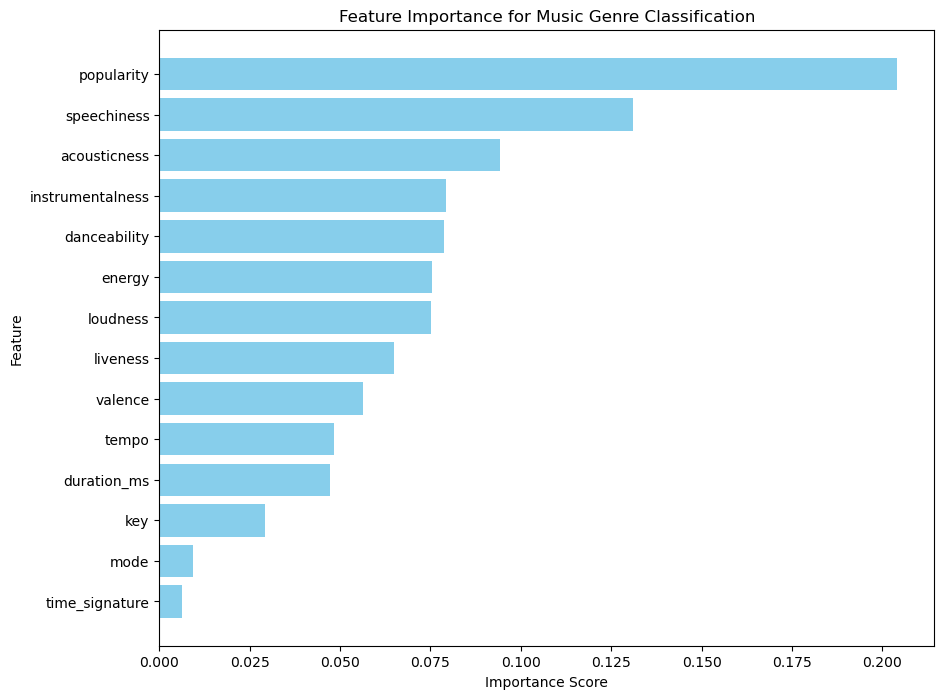

In [9]:
#train randomforestclassifier
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

#extract feature importance
features = rf.feature_importances_

#dataframe
features_df = pd.DataFrame({
    'Features': X.columns,
    'Importance': features
}).sort_values(by = 'Importance', ascending = False)

#plot features
plt.figure(figsize = (10, 8))
plt.barh(features_df['Features'], features_df['Importance'], color='skyblue')
plt.title('Feature Importance for Music Genre Classification')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()

This plot shows the importance of each feature for music genre classification. We can
see that popularity, speechiness, and acousticness lead in importance, while key,
mode, and time_signatures importance is significantly less.

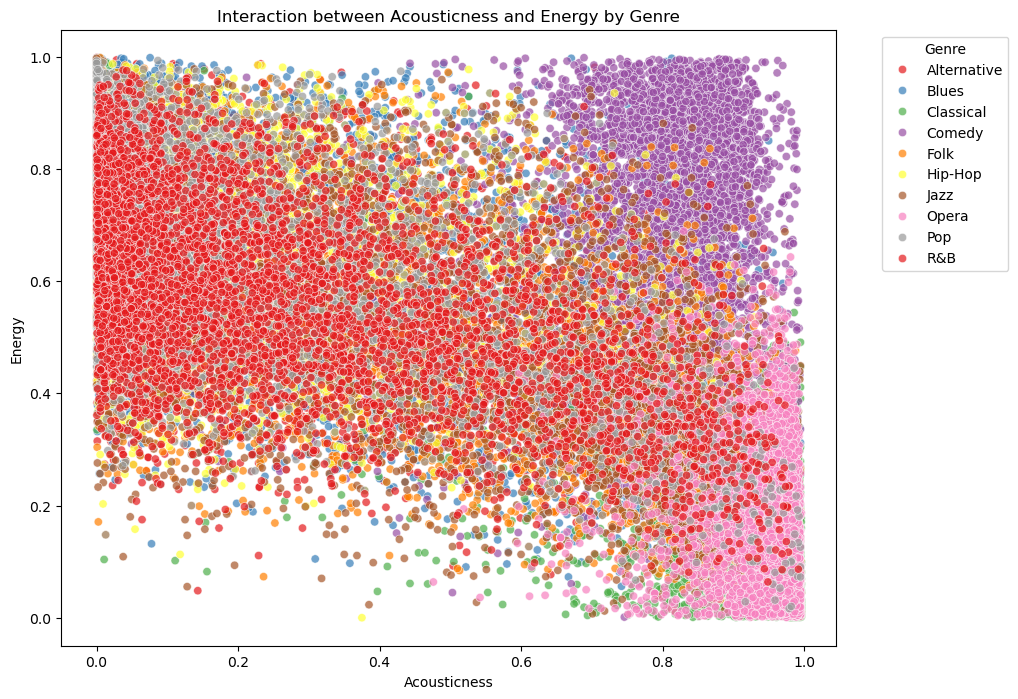

In [11]:
#Create scatter plot for acousticness vs energy
plt.figure(figsize=(10, 8))
sns.scatterplot(x='acousticness', y='energy', hue='genre', data=all_genres, palette='Set1', alpha=0.7)

#Labels
plt.title('Interaction between Acousticness and Energy by Genre')
plt.xlabel('Acousticness')
plt.ylabel('Energy')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

This plot shows how acousticness and energy vary across genres. Classical and Jazz,
and opera tend to have high acousticness and low energy, while pop, hip-hop, and
alternative have low acousticness and high energy. This interaction is crucial for
distinguishing between genres that might otherwise share similar features like tempo.

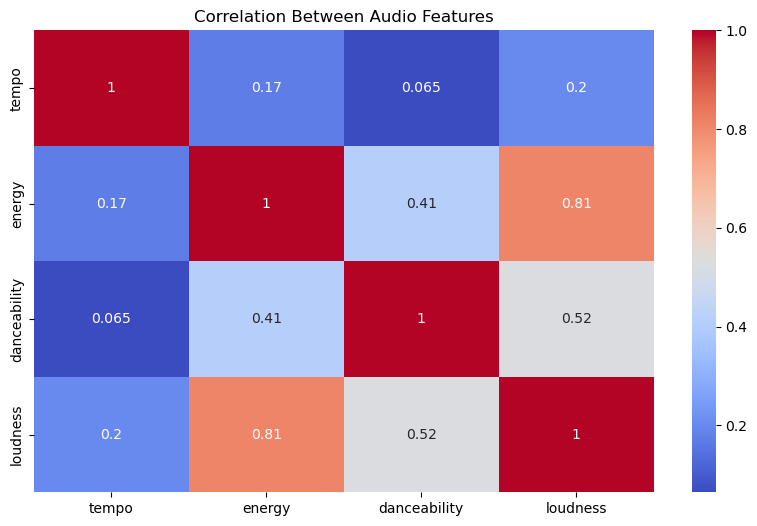

In [13]:
#correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(all_genres[['tempo', 'energy', 'danceability', 'loudness']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Audio Features')
plt.show()

This heatmap shows the correlation between the main numerical features. We can see
high correlation between energy and loudness, indicating that louder songs tend to have
higher energy.

Findings from data exploration:
There is a strong correlation between tempo and danceability. When analyzing the
dataset, I found that the tempo and danceability show a strong positive correlation,
especially for genres such as pop and hip-hop. Faster tempos tend to coincide with
higher dance ability scores. This suggests that tempo plays a significant role in
determining the danceability of a song.
Genre-specific artist associations. By encoding the artist’s most common genre, I’ve
noticed that certain artists are strongly associated with specific genres. In contrast,
some artists produce songs across multiple genres. Using the artist’s most common
genre as a feature improves model accuracy as it adds domain specific information.
However, it can introduce blind sports, as songs from artists who are categorized over
multiple genres may be misclassified due to genre bias.
Interaction between acousticness and energy. High acousticness is normally
associated with low energy in genres such as classical, folk, and jazz. However, genres
such as hip-hop and pop tend to have low acousticness and high energy. This
interaction help distinguish between genres that share common features like tempo but
differ in how they balance acousticness and energy. For example, folk and classical
have overlapping tempos but are very different in acousticness and energy levels.
Feature importance analysis from the gradient boosting model shows that popularity,
speechiness, and acousticness are the most important predictors. Less important
features are key, mode, and time signature. The dominance of popularity, speechiness,
and acousticness as predictive features highlight the significance of these
characteristics in genre classification. 

Initial design:
I decided to use features directly available from the dataset like tempo, energy, etc.
while handling categorical variables like key, mode, and time signature using label
encoding. Encoding the artist’s most common genre was a good decision as this feature
provided strong domain knowledge about the artist’s likely genre, improving the model
performance.
Feature selection was based on insights from the dataset exploration. Features like
tempo, danceability, and energy showed strong correlations with genre. Encoding the
artist’s most common genre was important as it added useful prior knowledge about
the artist’s typical style.
I replaced missing or invalid values in the tempo column with imputation using the
median value. This ensured consistency without introducing possible significant bias.
I chose random forest and gradient boosting models. Random forest was selected for its
robustness and ability to handle high-dimensional data. Gradient boosting was chosen
for its performance in structured data and its ability to capture complex interactions
between the features.
Pipeline structure. I use scikit-learn pipeline to ensure reproducibility and modularity.
The pipeline included standardscaler and model training, allowing for consistent
preprocessing across training and test data.
Initially, I used default setting for hyperparameter tuning and later fine-tuned key
parameters like n_estimators, learning_rate, and max_depth.
Intermediary system design:
I used gridsearchcv to optimize hyperparameters for gradientboosting. Parameters like
n_estimators, learning_rate, max_depth, and min_samples_split were tuned to find the
best performance and decrease overfitting.
Hyperparameter tuning was essential for improving model accuracy and preventing
overfitting as by tuning the parameters I was able to improve the gradient boosting
model performance on unseen data.
I explored additional feature interactions such as the energy to danceability ration with
provided a bettering understanding of how energy has an influence on genre
classification. This feature proved particularly useful for genres like pop and hip-hop.
Feature engineering added meaningful interactions between features. The energy to
dance ratio helped me to improve predictions for genres with energy significance.
Choosing the best system:
Gradient boosting classifier was the most accurate and interpretable, making it the best
system.
The accuracy of gradient boosting model consistently achieved high accuracy in crossvalidation and test sets, with an optimal balance between precision and recall for
different genres.
The models interpreability was improved by analyzing the feature importance,
highlighting the relevance of key features like danceability and energy.
One novel aspect of this system was encoding the artist’s most common genre, which
added specific knowledge and improved accuracy of predictions.
The including on energy to danceability ratio addedextra insights into how energy
influenced genre classification.

In [15]:
#defing param
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

#create randomizedsearchcv with randomforestclassifier
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter = 10, cv = 3, verbose = 2, random_state = 42, n_jobs = -1)

#fit random search on training data
rf_random.fit(X_train, y_train)

#get best hyperparamter
rf_best_params = rf_random.best_params_

#display
rf_best_params

Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 300,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_depth': 30,
 'bootstrap': True}

In [16]:
#initilize gradient boosting classifier
gb = GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state = 42)

#train gb
gb.fit(X_train, y_train)

#predict validation set
y_pred = gb.predict(X_val)

#calc accuarcy
accuracy = accuracy_score(y_val, y_pred)

#display
accuracy

0.6518

In [17]:
#define pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', GradientBoostingClassifier(random_state=42))
])

#define param
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__subsample': [0.8, 1.0]
}

#initialize gridsearchcv
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

#fit model
grid_search.fit(X_train, y_train)

#get best params
grid_best_params = grid_search.best_params_
grid_best_score = grid_search.best_score_

#display
grid_best_params
grid_best_score

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


0.6606500000000001

In [18]:
#evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)
test_accuracy = accuracy_score(y_val, y_pred)

test_accuracy

0.657

In [19]:
#create most common genre map
artist_genre_map = all_genres.groupby('artist_name')['genre'].agg(lambda x: x.value_counts().idxmax()).to_dict()

#add most common genre to artist train
all_genres['artist_most_common_genre'] = all_genres['artist_name'].map(artist_genre_map)

#handle missing values
most_common_genre = all_genres['genre'].value_counts().idxmax()
all_genres['artist_most_common_genre'].fillna(most_common_genre, inplace=True)

#add most common genre to artist test
test_data['artist_most_common_genre'] = test_data['artist_name'].map(artist_genre_map)

#handle missing artist in test set
test_data['artist_most_common_genre'].fillna(most_common_genre, inplace=True)

le = LabelEncoder()

#encode in both test and train
all_genres['artist_most_common_genre_encoded'] = le.fit_transform(all_genres['artist_most_common_genre'])
test_data['artist_most_common_genre_encoded'] = le.transform(test_data['artist_most_common_genre'])

#include incode in trainset
X_train = all_genres.drop(columns=['instance_id', 'artist_name', 'track_name', 'track_id', 'genre', 'artist_most_common_genre'])
y_train = all_genres['genre']

X_test = test_data.drop(columns=['instance_id', 'artist_name', 'track_name', 'track_id', 'artist_most_common_genre'])

#train model using gb
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=5, n_estimators=200,
                           random_state=42)

In [21]:
#make predictions using the trained Gradient Boosting model
test_predictions = gb_model.predict(X_test)

# create DataFrame 
submission_df = pd.DataFrame({
    'instance_id': test_data['instance_id'],
    'genre': test_predictions
})

In [23]:
#save the predictions to a CSV file in the required format
submission_df.to_csv('submission_predictions5.csv', index=False)

#Display 
print("Submission CSV created successfully!")

Submission CSV created successfully!


In [25]:
#energy danceability ratio
all_genres['energy_danceability_ratio'] = all_genres['energy'] / all_genres['danceability']
all_genres.head()

,instance_id,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,loudness,mode,speechiness,tempo,time_signature,valence,genre,artist_most_common_genre,artist_most_common_genre_encoded,energy_danceability_ratio
0,134768,Freddie Gibbs,Triple Threat,12NwYmQT1Mm7gkrCjIuq0d,45,0.02520,0.850,178422,0.412,0.00000,...,-7.845,0,0.2360,130.990,3,0.663,Alternative,Alternative,0,0.484706
1,97297,Three Days Grace,No More,4yDs61mzPcTod9qrBUE3H9,45,0.00261,0.271,225493,0.916,0.00000,...,-3.141,1,0.0581,197.817,3,0.286,Alternative,Alternative,0,3.380074
2,88412,Solange,Don't You Wait,0AmkrjMDff4ICVNxQhppZA,45,0.27900,0.833,245907,0.579,0.69200,...,-6.568,0,0.0800,110.043,3,0.514,Alternative,R&B,9,0.695078
3,172572,Amy Grant,"Baby, Baby",25AmLrQC1b3Hz9FUGZXF1S,58,0.42600,0.702,236973,0.901,0.00153,...,-4.450,0,0.0264,97.862,3,0.919,Alternative,Alternative,0,1.283476
4,194415,empty_field,Livin Right,6KmnejQFYdWUVUJh6zwEce,46,0.00114,0.539,209760,0.915,0.00000,...,-4.251,1,0.0601,88.051,3,0.435,Alternative,Comedy,3,1.697588


Interoperability of chose model:
One of the advantages of gradient boosting is that it allows for us to extract feature
importance, which indicates the contribution of each feature to the predictions.
However, individual predictions may be harder to explain due to the complex interaction
between features.
Comparing it to a simpler model such as KNN, KNN is less interpretable and less
effective in high-dimensional data so it is unlikely to perform as well as gradient
boosting could. It is less effective in capturing complex relationships in the data so it is
not very suitable for music genre classification.
Comparing to a more complex model, gradient boosting is more interpretable than
neural networks and slightly more complex than random forest. It makes it a good
balance between interpretability and predictive power.